In [17]:
# =========================
# 0) IMPORTACIONES
# =========================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.multioutput import MultiOutputClassifier
from sklearn.base import clone

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    hamming_loss,
    jaccard_score,
    make_scorer
)

from sklearn.preprocessing import MultiLabelBinarizer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid", context="notebook")

In [18]:
RUTA_TRAIN = "Datos_Laboratorio3.csv"
RUTA_TEST = "Datos test Lab3.csv"

df = pd.read_csv(RUTA_TRAIN, sep=";", encoding="latin-1")
df_test = pd.read_csv(RUTA_TEST, sep=";", encoding="latin-1")

print("Dimensiones del conjunto de entrenamiento:", df.shape)
print("Dimensiones del conjunto de prueba:", df_test.shape)
print("\nColumnas:\n", df.columns.tolist())

display(df.head())
df.info()
display(df.describe(include="all").T)

Dimensiones del conjunto de entrenamiento: (9698, 26)
Dimensiones del conjunto de prueba: (302, 26)

Columnas:
 ['Edad', 'Gnereo', 'Peso', 'Altura', 'BMI', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Horas_sueño', 'Entrenamiento_preferido', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua', 'Plan_entrenamiento', 'Plan_nutrición']


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Horas_sueño,Entrenamiento_preferido,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,Funcional,3,98,0,0,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,Funcional,4,105,0,0,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,Fuerza,1,88,0,0,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,Funcional,5,96,0,0,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,Balance,3,120,0,1,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


<class 'pandas.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Gnereo                   9698 non-null   str    
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   str    
 6   Condicion_salud          9698 non-null   str    
 7   Nivel_Actividad          9698 non-null   str    
 8   Nivel_experiencia        9698 non-null   str    
 9   Dieta_preferida          9698 non-null   str    
 10  Horas_sueño              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   str    
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible        9698 non-null   int64  
 14  Tiene_alergia            9698 non-n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Edad,9698.0,NaN,NaN,NaN,45.112601,17.641045,15.0,30.0,45.0,61.0,75.0
Gnereo,9698,3,Femenino,4719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Peso,9687.0,NaN,NaN,NaN,92.622515,27.383913,45.0,68.8,92.6,116.5,140.0
Altura,9698.0,NaN,NaN,NaN,1.775047,0.158754,1.5,1.64,1.78,1.91,2.05
BMI,9698.0,NaN,NaN,NaN,30.131391,10.605675,10.93,21.62,29.19,37.06,62.09
Objetivo,9698,5,Ganancia muscular,2757,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Condicion_salud,9698,7,Ninguno,6030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nivel_Actividad,9698,3,Moderado,3594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nivel_experiencia,9698,3,Intermedio,4100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dieta_preferida,9698,5,No-Vegetariano,2456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
faltantes = df.isna().sum().sort_values(ascending=False)
duplicados = df.duplicated().sum()

print("Duplicados:", duplicados)
print("\nValores faltantes por columna:\n")
display(faltantes.to_frame("n_faltantes"))

unicos = df.nunique().sort_values()
display(unicos.to_frame("n_unicos"))

Duplicados: 0

Valores faltantes por columna:



,n_faltantes
Peso,11
Edad,0
Gnereo,0
Altura,0
BMI,0
Objetivo,0
Condicion_salud,0
Nivel_Actividad,0
Nivel_experiencia,0
Dieta_preferida,0


,n_unicos
Problemas_digestivos,2
Tiene_alergia,2
Alcohol,2
Fumador,2
Nivel_experiencia,3
Nivel_Actividad,3
Gnereo,3
Plan_nutrición,4
Plan_entrenamiento,4
Dieta_preferida,5


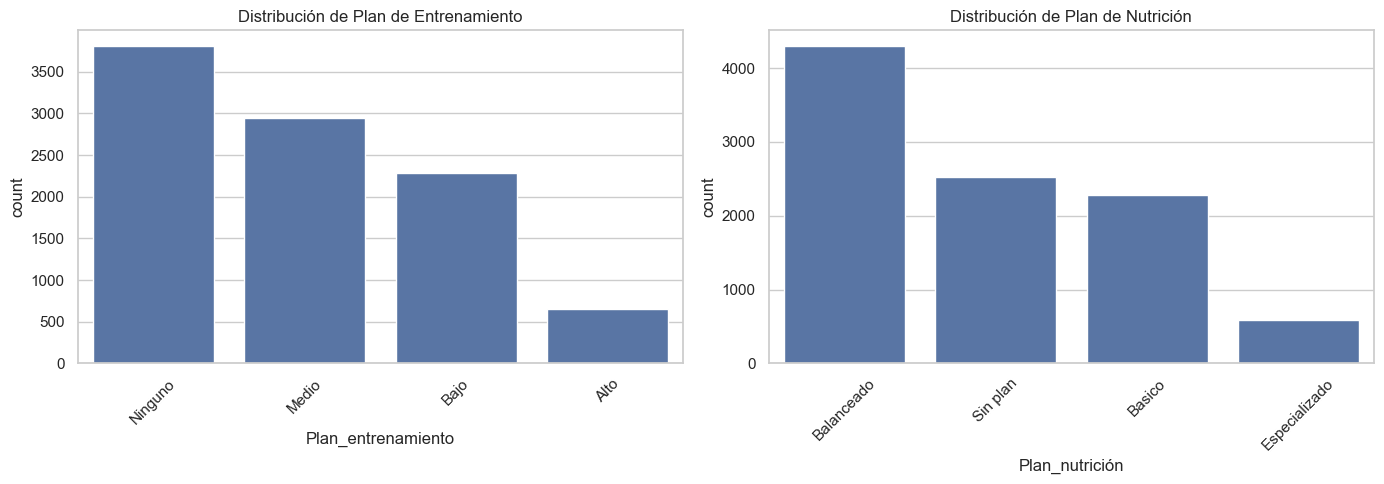

Distribución Plan de Entrenamiento:


,proporción
Plan_entrenamiento,
Ninguno,0.392555
Medio,0.303671
Bajo,0.236131
Alto,0.067643


Distribución Plan de Nutrición:


,proporción
Plan_nutrición,
Balanceado,0.443081
Sin plan,0.260054
Basico,0.235822
Especializado,0.061044


In [20]:
TARGET_ENTRENAMIENTO = "Plan_entrenamiento"
TARGET_NUTRICION ="Plan_nutrición"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=TARGET_ENTRENAMIENTO, order=df[TARGET_ENTRENAMIENTO].value_counts().index, ax=axes[0])
axes[0].set_title("Distribución de Plan de Entrenamiento")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x=TARGET_NUTRICION, order=df[TARGET_NUTRICION].value_counts().index, ax=axes[1]) 
axes[1].set_title("Distribución de Plan de Nutrición")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Distribución Plan de Entrenamiento:")
display(df[TARGET_ENTRENAMIENTO].value_counts(normalize=True).rename("proporción").to_frame())

print("Distribución Plan de Nutrición:")
display(df[TARGET_NUTRICION].value_counts(normalize=True).rename("proporción").to_frame())

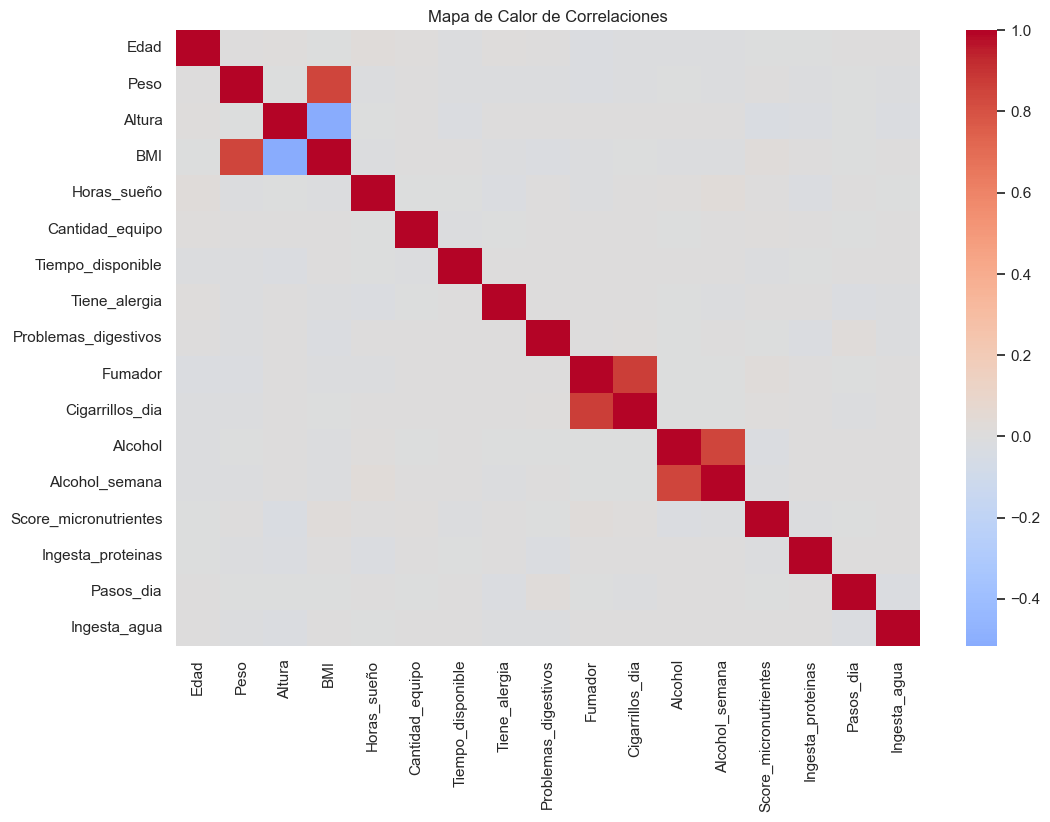

In [21]:
num_cols_tmp = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 8))
corr = df[num_cols_tmp].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Mapa de Calor de Correlaciones")
plt.show()

In [22]:
TARGETS = [TARGET_ENTRENAMIENTO, TARGET_NUTRICION]

X = df.drop(columns=TARGETS)
y_ent = df[TARGET_ENTRENAMIENTO].copy()
y_nut = df[TARGET_NUTRICION].copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Columnas numéricas:", len(num_cols), num_cols)
print("Columnas categóricas:", len(cat_cols), cat_cols)

Columnas numéricas: 17 ['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueño', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']
Columnas categóricas: 7 ['Gnereo', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido']


In [23]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

In [24]:
def entrenar_y_evaluar_objetivo(
    X, y, target_name, modelo_nombre, modelo_base, param_grid,
    preprocessor, random_state=42, test_size=0.2, cv_folds=5, scoring="f1_weighted"
):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo_base)
    ])
    
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    resultados = {
        "objetivo": target_name,
        "modelo": modelo_nombre,
        "cv_best_score_f1_weighted": grid.best_score_,
        "test_precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "test_recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "test_f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "test_precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "test_recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "best_params": grid.best_params_
    }
    
    artefactos = {
        "grid": grid,
        "best_model": best_model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred
    }
    
    return resultados, artefactos

In [27]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=6000)

param_grid_log= [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["lbfgs", "newton-cg"],
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["elasticnet"],
        "model__l1_ratio": [0.2, 0.5, 0.8],
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    }
]

resumen_resultados = []
artefactos_modelos = {}

for target_name, y_obj in [(TARGET_ENTRENAMIENTO, y_ent), (TARGET_NUTRICION, y_nut)]:
    res, art = entrenar_y_evaluar_objetivo(
        X=X,
        y=y_obj,
        target_name=target_name,
        modelo_nombre="RegresionLogistica",
        modelo_base=log_reg,
        param_grid=param_grid_log,
        preprocessor=preprocessor,
        random_state=RANDOM_STATE,
        test_size=0.30,
        cv_folds=5,
        scoring="f1_weighted"
    )
    resumen_resultados.append(res)
    artefactos_modelos[(target_name, "RegresionLogistica")] = art
    
    print(f"\n===== {target_name} | RegresionLogistica =====")
    print("Mejores hiperparámetros:")
    print(res["best_params"])
    print("\nClassification report (test):")
    print(classification_report(art["y_test"], art["y_pred"], zero_division=0))
    

Fitting 5 folds for each of 72 candidates, totalling 360 fits

===== Plan_entrenamiento | RegresionLogistica =====
Mejores hiperparámetros:
{'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}

Classification report (test):
              precision    recall  f1-score   support

        Alto       0.90      0.85      0.87       197
        Bajo       0.80      0.79      0.80       687
       Medio       0.89      0.89      0.89       884
     Ninguno       0.94      0.95      0.95      1142

    accuracy                           0.89      2910
   macro avg       0.88      0.87      0.88      2910
weighted avg       0.89      0.89      0.89      2910

Fitting 5 folds for each of 72 candidates, totalling 360 fits

===== Plan_nutrición | RegresionLogistica =====
Mejores hiperparámetros:
{'model__C': 1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}

Classification report (test):
               precision    recall  f1-

In [28]:
tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
param_grid_tree = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__class_weight": [None, "balanced"]
}

for target_name, y_obj in [(TARGET_ENTRENAMIENTO, y_ent), (TARGET_NUTRICION, y_nut)]:
    res, art = entrenar_y_evaluar_objetivo(
        X=X,
        y=y_obj,
        target_name=target_name,
        modelo_nombre="ArbolDecision",
        modelo_base=tree,
        param_grid=param_grid_tree,
        preprocessor=preprocessor,
        random_state=RANDOM_STATE,
        test_size=0.30,
        cv_folds=5,
        scoring="f1_weighted"
    )
    resumen_resultados.append(res)
    artefactos_modelos[(target_name, "ArbolDecision")] = art
    
    print(f"\n{target_name} | ArbolDecision")
    print("Mejores hiperparámetros:")
    print(res["best_params"])
    print("\nClassification report (test):")
    print(classification_report(art["y_test"], art["y_pred"], zero_division=0))

Fitting 5 folds for each of 480 candidates, totalling 2400 fits

Plan_entrenamiento | ArbolDecision
Mejores hiperparámetros:
{'model__class_weight': None, 'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Classification report (test):
              precision    recall  f1-score   support

        Alto       1.00      1.00      1.00       197
        Bajo       1.00      1.00      1.00       687
       Medio       1.00      1.00      1.00       884
     Ninguno       1.00      1.00      1.00      1142

    accuracy                           1.00      2910
   macro avg       1.00      1.00      1.00      2910
weighted avg       1.00      1.00      1.00      2910

Fitting 5 folds for each of 480 candidates, totalling 2400 fits

Plan_nutrición | ArbolDecision
Mejores hiperparámetros:
{'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_spl

In [31]:
df_resultados = pd.DataFrame(resumen_resultados)
columnas_mostrar = [
    "objetivo", "modelo",
    "cv_best_score_f1_weighted",
    "test_precision_weighted",
    "test_recall_weighted",
    "test_f1_weighted",
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro"
]

display(df_resultados[columnas_mostrar].sort_values(["objetivo", "test_f1_weighted"], ascending=[True, False]))
idx_mejor = df_resultados.groupby("objetivo")["test_f1_weighted"].idxmax()
df_mejores = df_resultados.loc[idx_mejor].sort_values("objetivo").reset_index(drop=True)
print("=== Mejor modelo por objetivo (criterio: test_f1_weighted) ===")
display(df_mejores[columnas_mostrar])

df_resultados.to_csv("tabla_comparativa_modelos_lab3.csv", index=False, sep=";")
print("Tabla comparativa exportada.")

,objetivo,modelo,cv_best_score_f1_weighted,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_precision_macro,test_recall_macro,test_f1_macro
2,Plan_entrenamiento,ArbolDecision,0.998822,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
0,Plan_entrenamiento,RegresionLogistica,0.893929,0.888565,0.889003,0.888713,0.881952,0.871210,0.876384
3,Plan_nutrición,ArbolDecision,0.996615,0.996918,0.996907,0.996910,0.997107,0.996430,0.996764
1,Plan_nutrición,RegresionLogistica,0.825388,0.821849,0.823368,0.822132,0.799529,0.771083,0.783593


=== Mejor modelo por objetivo (criterio: test_f1_weighted) ===


,objetivo,modelo,cv_best_score_f1_weighted,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_precision_macro,test_recall_macro,test_f1_macro
0,Plan_entrenamiento,ArbolDecision,0.998822,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000
1,Plan_nutrición,ArbolDecision,0.996615,0.996918,0.996907,0.99691,0.997107,0.99643,0.996764


Tabla comparativa exportada.


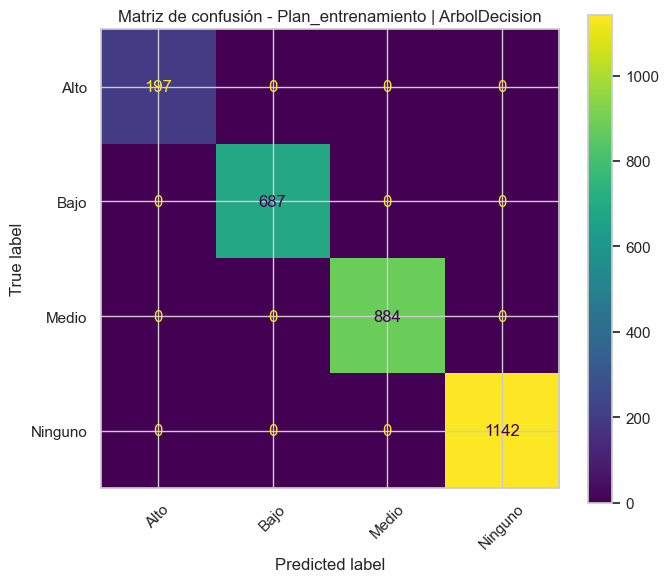

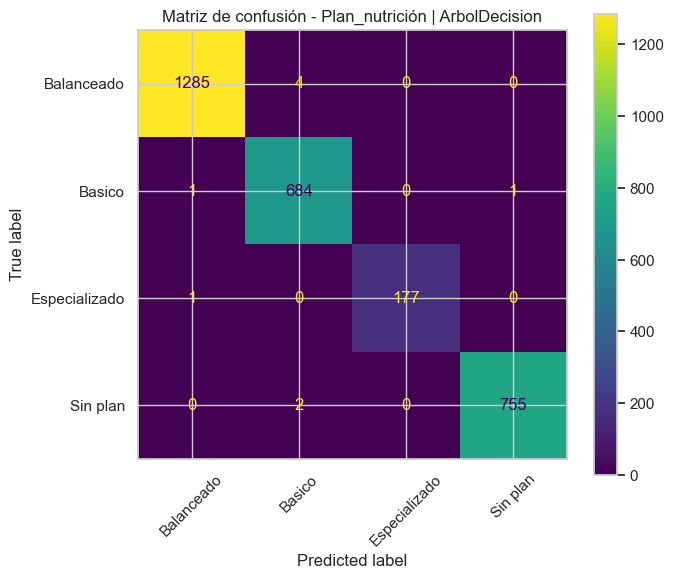

In [32]:
for _, row in df_mejores.iterrows():
    obj = row["objetivo"]
    modelo = row["modelo"]
    art = artefactos_modelos[(obj, modelo)]
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        art["y_test"], art["y_pred"], ax=ax, xticks_rotation=45
    )
    ax.set_title(f"Matriz de confusión - {obj} | {modelo}")
    plt.tight_layout()
    plt.show()

In [36]:
def get_feature_names_from_pipeline(fitted_pipeline, num_cols, cal_cols):
    prep = fitted_pipeline.named_steps["preprocessor"]
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    all_features = num_cols + cat_feature_names
    return all_features

def importancias_logistica(fitted_pipeline, num_cols, cat_cols, top_n=15):
    model = fitted_pipeline.named_steps["model"]
    feats = get_feature_names_from_pipeline(fitted_pipeline, num_cols, cat_cols)
    
    imp = np.mean(np.abs(model.coef_), axis=0)
    df_imp = pd.DataFrame({"feature": feats, "importance": imp}).sort_values("importance", ascending=False)
    return df_imp.head(top_n), df_imp

def importancias_arbol(fitted_pipeline, num_cols, cat_cols, top_n=15):
    model = fitted_pipeline.named_steps["model"]
    feats = get_feature_names_from_pipeline(fitted_pipeline, num_cols, cat_cols)
    imp = model.feature_importances_
    df_imp = pd.DataFrame({"feature": feats, "importance": imp}).sort_values("importance", ascending=False)
    return df_imp.head(top_n), df_imp

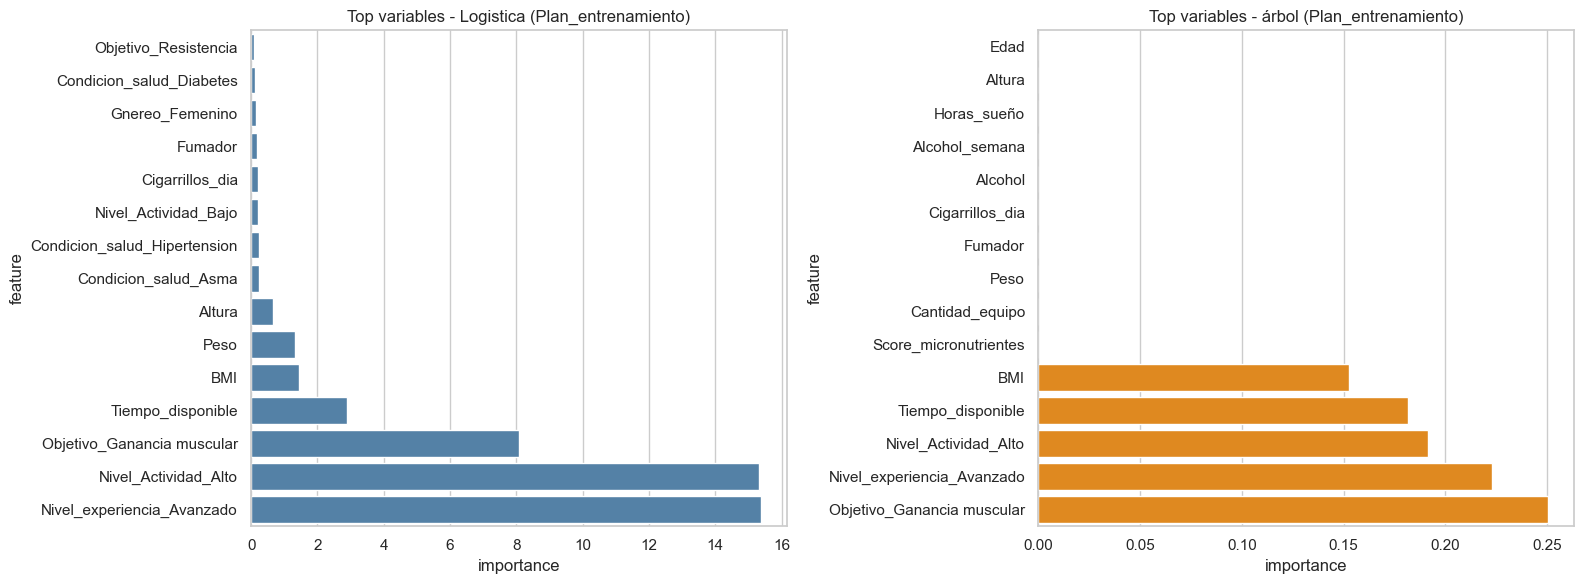

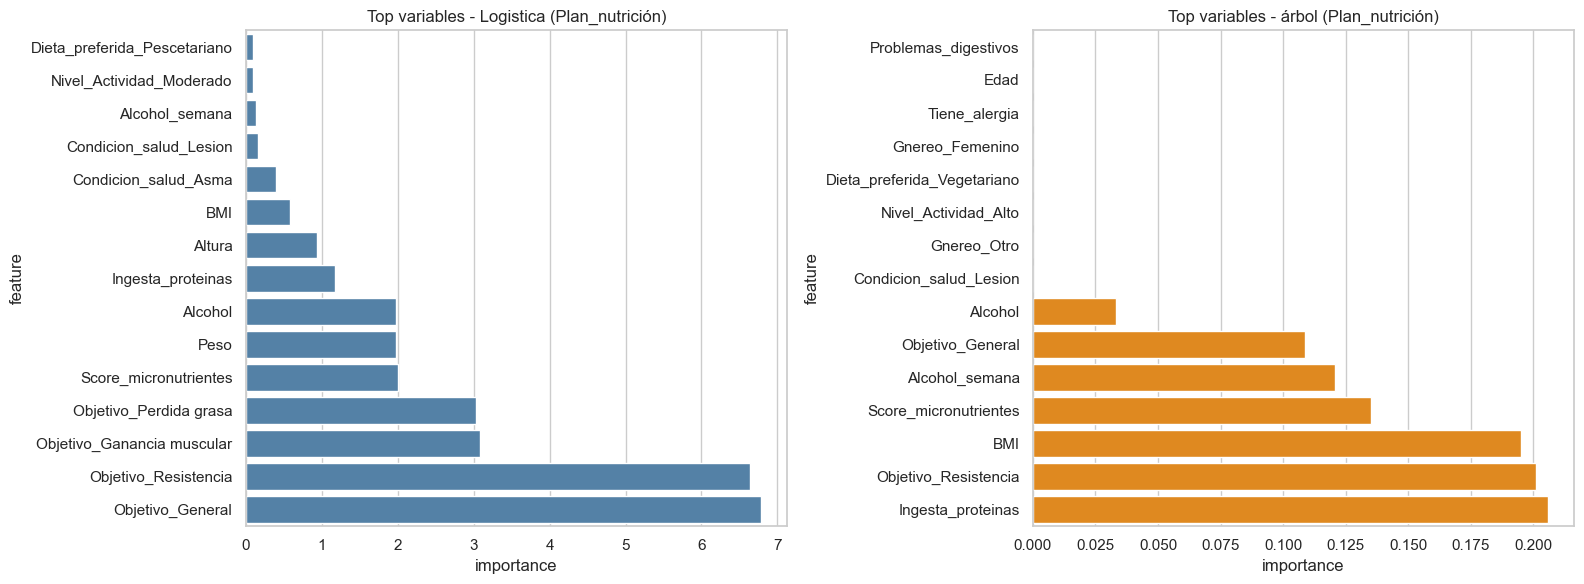

,feature,importance,objetivo,modelo
0,Nivel_experiencia_Avanzado,15.389537,Plan_entrenamiento,RegresionLogistica
1,Nivel_Actividad_Alto,15.317097,Plan_entrenamiento,RegresionLogistica
2,Objetivo_Ganancia muscular,8.072664,Plan_entrenamiento,RegresionLogistica
3,Tiempo_disponible,2.881167,Plan_entrenamiento,RegresionLogistica
4,BMI,1.439562,Plan_entrenamiento,RegresionLogistica
5,Peso,1.316102,Plan_entrenamiento,RegresionLogistica
6,Altura,0.650865,Plan_entrenamiento,RegresionLogistica
7,Condicion_salud_Asma,0.232405,Plan_entrenamiento,RegresionLogistica
8,Condicion_salud_Hipertension,0.222958,Plan_entrenamiento,RegresionLogistica
9,Nivel_Actividad_Bajo,0.210551,Plan_entrenamiento,RegresionLogistica


Importancias esportadas.


In [37]:
importancias_resumen = []
for obj in [TARGET_ENTRENAMIENTO, TARGET_NUTRICION]:
    pipe_log = artefactos_modelos [(obj, "RegresionLogistica")]["best_model"]
    top_log, full_log = importancias_logistica(pipe_log, num_cols, cat_cols, top_n=15)
    top_log["objetivo"] = obj
    top_log["modelo"] = "RegresionLogistica"
    importancias_resumen.append(top_log)
    
    pipe_tree = artefactos_modelos[(obj, "ArbolDecision")]["best_model"]
    top_tree, full_tree = importancias_arbol(pipe_tree, num_cols, cat_cols, top_n=15)
    top_tree["objetivo"] = obj
    top_tree["modelo"] = "ArbolDecision"
    importancias_resumen.append(top_tree)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=top_log.sort_values("importance", ascending=True),
                x="importance", y="feature", ax=axes[0], color="steelblue")
    axes[0].set_title(f"Top variables - Logistica ({obj})")
    sns.barplot(data=top_tree.sort_values("importance", ascending=True),
                            x="importance", y="feature", ax=axes[1], color="darkorange")
    axes[1].set_title(f"Top variables - árbol ({obj})")
    
    plt.tight_layout()
    plt.show()
    
df_importancias = pd.concat(importancias_resumen, ignore_index=True)
display(df_importancias.head(30))
df_importancias.to_csv("importancia_variables_lab3.csv", index=False, sep=";")
print("Importancias esportadas.")

In [38]:
MAX_DEPTH_REGLAS = 3

for obj in [TARGET_ENTRENAMIENTO, TARGET_NUTRICION]:
    pipe_tree = artefactos_modelos[(obj, "ArbolDecision")]["best_model"]
    tree_model = pipe_tree.named_steps["model"]
    feat_names = get_feature_names_from_pipeline(pipe_tree, num_cols, cat_cols)
    reglas = export_text(tree_model, feature_names=feat_names, max_depth=MAX_DEPTH_REGLAS)
    print(f"\n{'='*80}\nREGLAS DEL ÁRBOL PARA: {obj}\n{'='*80}")
    print(reglas[:5000])


REGLAS DEL ÁRBOL PARA: Plan_entrenamiento
|--- Nivel_Actividad_Alto <= 0.50
|   |--- Nivel_experiencia_Avanzado <= 0.50
|   |   |--- BMI <= 0.18
|   |   |   |--- Objetivo_Ganancia muscular <= 0.50
|   |   |   |   |--- class: Ninguno
|   |   |   |--- Objetivo_Ganancia muscular >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- BMI >  0.18
|   |   |   |--- Tiempo_disponible <= 0.25
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Tiempo_disponible >  0.25
|   |   |   |   |--- truncated branch of depth 2
|   |--- Nivel_experiencia_Avanzado >  0.50
|   |   |--- Tiempo_disponible <= 0.25
|   |   |   |--- BMI <= 0.18
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- BMI >  0.18
|   |   |   |   |--- class: Medio
|   |   |--- Tiempo_disponible >  0.25
|   |   |   |--- Objetivo_Ganancia muscular <= 0.50
|   |   |   |   |--- class: Medio
|   |   |   |--- Objetivo_Ganancia muscular >  0.50
|   |   |   |   |--- truncated branch of depth 2
|--- N

## Análisis de resultados 

1. ¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?

    Las variables más relacionadas con los pleanes recomendados son los indicadores físicos y demográficos como la edad, el BMI, el historial de lesiones, y la frecuencia de actividad actual para el plan de entrenamiento. Mientras tanto, para el plan de nutrición destacan hábitos alimenticios actuales, las deficiencias nutricionales, los objetivos de composición corporal y las condiciones de salud previas. El análisis de importancia revela que tras la condición onehot, tanto las variables numéricas como las categóricas tiene poder discriminatorio complementario, con el árbol de decisión priorizando características con fuerte capacidad de partición del espacio de datos.

2. ¿Existen variables que podrían ser redundantes o poco informativas?

    Entre las variables que pueden ser redundantes o poco informativas están variables con importancia cercana a cero en ambos modelos de árboles de decisión, junto con coeficientes prácticamente nulos en regresión logísitica tras regularización L1/L2, indican redundancia. Por otro lado, el mapa de correlaciones reveló variables altamente correlacionadas que son descartadas por mecanismos de regularización y características con altas tasas de imputación (valores faltantes reemplazados) tienden a ser menos confiables e informativas, sugiriendo que podrían ser eliminadas sin comprometer significativamente el desempeño del modelo.

3. ¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?

    Si, el modelo efectivamente reproduce adecuadamente las recomendaciones: F1-score ponderado superior a 0,997, precisión y recall ponderados superiores a 0,99 en ambos objetivos, indicando excelente identificación de categorías mayoritarias y minoritarias sin producir falsos positivos significativos. El subset accuracy del modelo multioutput es extremadamente alto, lo que confirma que predice correctamente ambos objetivos simultáneamente, sin embargo, estos valores cercanos a 1.0 sugieren posible sobreajuste o un conjunto de datos predecible, redirigiendo validación rigurosa en datos completamente nuevos de la plataforma SmartAlpes.

4. A partir de alguno de los modelos creados con árboles de decisión, describa en términos de reglas, las características que cumplen las variables involucradas en la recomendación que se da. Incluya además, la utilidad y la limitación que tienen este estilo de reglas en modelos de árboles de decisión principalmente en el proceso de explicabilidad del modelo.

    La utilidad principal del árbol está en su interpretación directa: proporciona caminos lógicos simples que usuarios y especialistas comprenden sin información técnica, permitiendo trazabilidad completa de cada recomendación y capturando la lógica que entrenadores personales aplicarían manualmente. Sin embargo, sus limitaciones incluyen inestabilidad estructural (pequeños cambios en datos generan árboles completamente diferentes), fragmentación del espacio en discontinuidades ortogonales que no reflejan relaciones continuas, tendencia al sobreajuste en profundidades sin restricción y sesgo hacia variables de alta cardinalidad; aunque interpretables individualmente, las reglas se vuelven un poco complejas cuando se consideran en conjunto, lo que limita la explicación integral del modelo.

5. ¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?

    Para integrarlo en una plataforma, implica replicar el pipeline entrenado (preprocessing + modelo) como una API REST que reciba datos del perfil del usuario en JSON, ejecute predicción y retorne recomendaciones de confianza. La plataforma debe presentar recomendaciones de forma amigable con opción de interpretación, validar entrada de datos contra rangos de entrenamiento, registrar decisiones para monitoreo y establecer procesos de A/B testing contra recomendaciones manuales, tecnicamente requiere serialización del modelo (joblib), versionamiento y alertas de degradación en métricas.

6. ¿Qué limitaciones tendría utilizar un sistema automático para recomendar planes de entrenamiento?

    las limitaciones técnicas incluyen la degradación por cambios en el perfil de usuarios (covariante shift), dependencia crítica de calidad de datos, falta de adaptación temporal y ausencia de interacción entre el usuario y el modelo. Lass limitaciones operacionales estan dadas por el reemplazo insuficiente del expertise humano que aporta contexto psicológico y motivación, riesgos de perpetuar sesgos de datos, responsabilidad legal y preocupaciones de privacidad en almacenamiento de perfiles, ademas, las métricas demasiado altas sugieren sobreajuste potencial y el desempeño puede degradar con usuarios que tienen objetivos desacoplados, requiriendo validación en datos no vistos y balance entre interpretabilidad y precisión.

7. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

    Los sesgos de datos incluyen sesgo de selección (usuarios ya en SmartAlpes no representan sedentarios), sesgo de supervivencia (usuarios que abandonaron tras ciertas recomendaciones ausentes), sesgo demográfico si hay concentración por género o edad y sesgo de imputación que introduce información artificial. Los sesgos en modelado provienen de la formulación binaria simplificadora del problema que no captura necesidades complejas, exclusión de variables relevantes (lesiones, horarios, equipamiento), uso de F1 ponderado que oculta desempeño pobre en clases minoritarias y sesgo del etiquetador (decisiones de entrenadores originales); la mitigación requiere estratificar validación por demográfia, recolectar feedback post-recomendación, auditar regularmente decisiones, incorporar revisión humana y documentar públicamente limitaciones.

In [39]:
mejor_por_obj = {}
for obj in [TARGET_ENTRENAMIENTO, TARGET_NUTRICION]:
    sub = df_resultados[df_resultados["objetivo"] == obj].sort_values("test_f1_weighted", ascending=False)
    mejor_modelo_nombre = sub.iloc[0]["modelo"]
    mejor_por_obj[obj] = mejor_modelo_nombre
    
print("Mejor modelo por objetivo: ", mejor_por_obj)

X_full = df.drop(columns=TARGETS)
y_full_ent = df[TARGET_ENTRENAMIENTO]
y_full_nut = df[TARGET_NUTRICION]

pipe_ent = clone(artefactos_modelos[(TARGET_ENTRENAMIENTO, mejor_por_obj[TARGET_ENTRENAMIENTO])]["best_model"])
pipe_nut = clone(artefactos_modelos[(TARGET_NUTRICION, mejor_por_obj[TARGET_NUTRICION])]["best_model"])

pipe_ent.fit(X_full, y_full_ent)
pipe_nut.fit(X_full, y_full_nut)

X_test_final = df_test.drop(columns=TARGETS, errors="ignore")

pred_ent = pipe_ent.predict(X_test_final)
pred_nut = pipe_nut.predict(X_test_final)

df_pred = df_test.copy()
df_pred[TARGET_ENTRENAMIENTO] = pred_ent
df_pred[TARGET_NUTRICION] = pred_nut
display(df_pred.head())

RUTA_SALIDA = "Datos test Lab3 - predicciones.csv"
df_pred.to_csv(RUTA_SALIDA, index=False, sep=";")
print("Archivo exportado en: ", RUTA_SALIDA)

Mejor modelo por objetivo:  {'Plan_entrenamiento': 'ArbolDecision', 'Plan_nutrición': 'ArbolDecision'}


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Horas_sueño,Entrenamiento_preferido,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,9.4,Flexibilidad,6,120,0,0,0,0.0,0,0.0,0.21,169.0,8468,2.57,Medio,Balanceado
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,8.0,Cardio,2,34,0,0,0,0.0,0,0.0,0.58,52.4,11967,3.73,Medio,Sin plan
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,9.4,Flexibilidad,1,52,0,0,0,0.0,0,0.0,0.37,189.5,15950,3.06,Medio,Basico
3,42,Femenino,103.5,1.67,37.11,General,Asma,Bajo,Principiante,No-Vegetariano,7.3,Fuerza,6,81,1,0,0,0.0,0,0.0,0.57,185.7,9384,2.18,Bajo,Sin plan
4,29,Masculino,76.0,2.02,18.63,Ganancia muscular,Ninguno,Bajo,Intermedio,Pescetariano,7.4,Balance,3,114,1,0,0,0.0,1,23.7,0.21,182.1,10070,3.32,Bajo,Balanceado


Archivo exportado en:  Datos test Lab3 - predicciones.csv


In [40]:
X_ml = df.drop(columns=TARGETS)
Y_ml = df[TARGETS].copy()

X_train_ml, X_test_ml, Y_train_ml, Y_test_ml = train_test_split(
    X_ml, Y_ml, test_size=0.30, random_state=RANDOM_STATE
)

def f1_weighted_promedio_multioutput(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f1s = []
    for i in range (y_true.shape[1]):
        f1s.append(f1_score(y_true[:, i], y_pred[:, i], average="weighted", zero_division=0))
    return float(np.mean(f1s))

scorer_multi = make_scorer(f1_weighted_promedio_multioutput, greater_is_better=True)
base_multi = MultiOutputClassifier(
    LogisticRegression(max_iter=6000, random_state=RANDOM_STATE)
)
pipe_multi = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", base_multi)
])

param_grid_multi = {
    "model__estimator__solver": ["liblinear", "lbfgs", "saga"],
    "model__estimator__C": [0.01, 0.1, 1, 10],
    "model__estimator__class_weight": [None, "balanced"]
}

cv_multi = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_multi = GridSearchCV(
    estimator=pipe_multi,
    param_grid=param_grid_multi,
    scoring=scorer_multi,
    cv=cv_multi,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_multi.fit(X_train_ml, Y_train_ml)
print("Best params multioutput:", grid_multi.best_params_)
print("Best CV score (f1 weighted promedio):", grid_multi.best_score_)
best_multi = grid_multi.best_estimator_
Y_pred_ml = best_multi.predict(X_test_ml)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params multioutput: {'model__estimator__C': 10, 'model__estimator__class_weight': None, 'model__estimator__solver': 'saga'}
Best CV score (f1 weighted promedio): 0.8523409977993703


In [45]:
subset_acc = np.mean(np.all(Y_test_ml.values == Y_pred_ml, axis=1))
h_loss = np.mean(Y_test_ml.values != Y_pred_ml)
y_true_flat = Y_test_ml.values.reshape(-1)
y_pred_flat = Y_pred_ml.reshape(-1)

f1_micro = f1_score(y_true_flat, y_pred_flat, average="micro", zero_division=0)
f1_macro = f1_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)
f1_weighted = f1_score(y_true_flat, y_pred_flat, average="weighted", zero_division=0)

true_sets = [[f"ENT:{r[0]}", f"NUT:{r[1]}"] for r in Y_test_ml.values]
pred_sets = [[f"ENT:{r[0]}", f"NUT:{r[1]}"] for r in Y_pred_ml]

mlb = MultiLabelBinarizer()
Y_true_bin = mlb.fit_transform(true_sets)
Y_pred_bin = mlb.transform(pred_sets)

jaccard_samples = jaccard_score(Y_true_bin, Y_pred_bin, average="samples", zero_division=0)
print("Subset accuracy: ", subset_acc)
print("Hamming loss: ", h_loss)
print("F1 micro (flattened): ", f1_micro)
print("F1 macro (flattened): ", f1_macro)
print("F1 weighted (flattened): ", f1_weighted)
print("Jaccard (samples): ", jaccard_samples)

Subset accuracy:  0.7474226804123711
Hamming loss:  0.138659793814433
F1 micro (flattened):  0.8613402061855671
F1 macro (flattened):  0.8422133730720278
F1 weighted (flattened):  0.8603382698577686
Jaccard (samples):  0.8233676975945017


In [46]:
for i, col in enumerate(TARGETS):
    print(f"\n===== Reporte para salida: {col} =====")
    print(classification_report(Y_test_ml.iloc[:, i], Y_pred_ml[:, i], zero_division=0))


===== Reporte para salida: Plan_entrenamiento =====
              precision    recall  f1-score   support

        Alto       0.93      0.89      0.91       218
        Bajo       0.83      0.80      0.81       686
       Medio       0.90      0.91      0.91       888
     Ninguno       0.93      0.96      0.94      1118

    accuracy                           0.90      2910
   macro avg       0.90      0.89      0.89      2910
weighted avg       0.90      0.90      0.90      2910


===== Reporte para salida: Plan_nutrición =====
               precision    recall  f1-score   support

   Balanceado       0.86      0.88      0.87      1252
       Basico       0.71      0.68      0.70       704
Especializado       0.76      0.68      0.72       183
     Sin plan       0.87      0.89      0.88       771

     accuracy                           0.82      2910
    macro avg       0.80      0.78      0.79      2910
 weighted avg       0.82      0.82      0.82      2910



In [ ]:
# Uso de Herramientas de IAG

## Declaración de Uso

### Herramienta Utiizada: Claude Haiku 4.5
### Tipos de Uso:

    - Depuración de código: identificación y corrección de errores de sintaxis en pandas. 
    - Generación inicial ocasional de código: En algunos casos se utilizó para generar esqueletos de funciones para importancias de variables.
    - Explicación teórica: diferencias entre regresión logística y árboles de decisión.
    - Redacción: Mejora del lenguaje técnico en reportes y análisis.

### Prompts Utilizados

    - Indicame como modificar la siguiente línea para corregir el error en Pandas: "AttributeError: 'DataFrame' object has no attribute 'sort'"
    - Cómo se debe calcular subset accuracy para problemas multioutput en scikit-learn?
    - Cuál es la diferencia entre .idmax() e idxmax() en pandas?
    - Corrige la sintaxis y posibles errores en la redacción y conceptos de las respuestas que formulé a las preguntas.
    - Cómo se deben manejar correctamente varuables categóricas con OneHotEncoder en el pipeline de scikit-learn?
    
### Análisis Crítico del Resultado

### ¿Qué partes del contenido generado fueron correctas y útiles?

    - Correcciones de sintaxis precisas como de .sort() a .sort_values(), o de idmax() a idxmax().
    - Soluciones para multioutput exactas y funcionalmente correctas. 
    - La estructura propuesta para el análisis proporcionó a cobertura completa de los temas.
    - Identificación rápida y eficaz de incompatibilidades entre funciones y tipos de datos.
    
### ¿Qué errores, impresiciones o limitaciones se identificaron?

    - Análisis genérico y teórico sin vincular métricas específicas del modelo.
    - Desconocimiento del contexto de SmartAlpes. 
    - no acceso a outputs reales del modelo ni capacidad de ejecutar el código por si mismo.
    - Imposibilidad de referenciar a valores concretos.

### ¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IAG y por qué?

    - Rechazado: Sugerencia de usar accuracy_score() directamente con multioutput.
    - Rechazado: Redacción muy genérica del análisis.
    - Validación manual: Cada corrección de código se ejecutó antes de aceptarla.
    - Adaptación: Propuesta de que la estructura se adaptara y especializara a dos objetivos (entrenamiento y nutrición).

### ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?

### APORTES PROPIOS DEL ESTUDIANTE

### ¿Qué fue desarrollado, modificado o decidido por el estudiante?

### ¿Qué ajustes se realizaron sobre el código o la explicación original?

### ¿Qué aprendizajes se obtuvieron del proceso?